<a href="https://colab.research.google.com/github/HunterTzou/DATA_201_SPRING_2026/blob/main/homework/Tzou_Hunter_DATA201_Week3_Assignment_Visualization_and_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 201 -- Week 3 Assignment

## Visualization + Linear Regression (R → Python Bridge)

**Submission:** Jupyter Notebook (.ipynb)\
**Dataset:** housing.csv\
**Focus:** Interpretation \> Syntax

------------------------------------------------------------------------

# Grading Rubric

| Category                         | Points |
|----------------------------------|--------|
| Visualization accuracy           | 20     |
| Visualization interpretation     | 20     |
| Regression implementation        | 20     |
| Regression interpretation        | 10     |
| Prediction workflow              | 20     |
| Integrated reasoning             | 10     |
| **Total**                        | **100**|

------------------------------------------------------------------------

# Part I -- Visualization (40 pts)

## A. Scatterplots and Aesthetics

1.  Create a scatterplot of **size vs price**.

    -   Label axes clearly.
    -   Add a meaningful title.

2.  Recreate the plot using `color = neighborhood` (use seaborn).

3.  Use transparency (`alpha`) to reduce overplotting.


### Short Answer (3--4 sentences)

-   What does seaborn automatically handle that matplotlib does not?
-   Why is transparency useful here?

Response:

- I think that seaborn automatically assigned a legend, the hue, and faceting.
- transparency is helpful because you could have several dots plotted on top of each other and you would not be able to see those plots underneath without transparency

Text(0.5, 1.0, 'Size vs. Price')

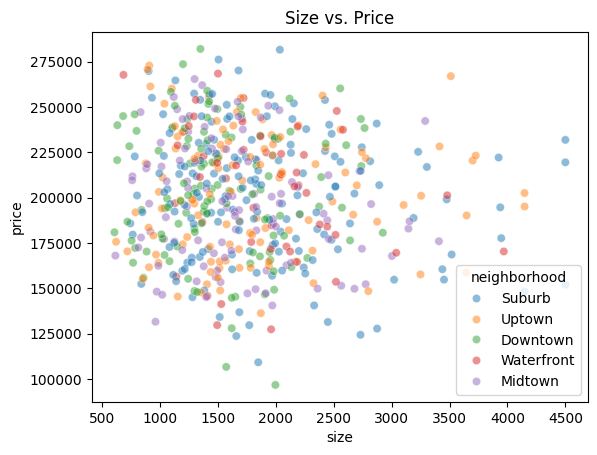

In [35]:
# PART 1 - A. Scatterplots and Aesthetics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/HunterTzou/DATA201/refs/heads/main/Dataset/housing.csv")

sns.scatterplot(data=df, x="size", y="price", hue="neighborhood", alpha = .5).set_title("Size vs. Price")

------------------------------------------------------------------------

## B. Small Multiples (Faceting)

Create small multiples of **size vs price**, separated by `bedrooms`.

-   Keep scales consistent.
-   Add a clear overall title.

### Question

Does the relationship between size and price look similar across bedroom
counts?

Response:

I would say that the patterns are fairly similar from 0-3 bedrooms and from 4-6 bedrooms.

Text(0.5, 1.02, 'Size vs Price by Number of Bedrooms')

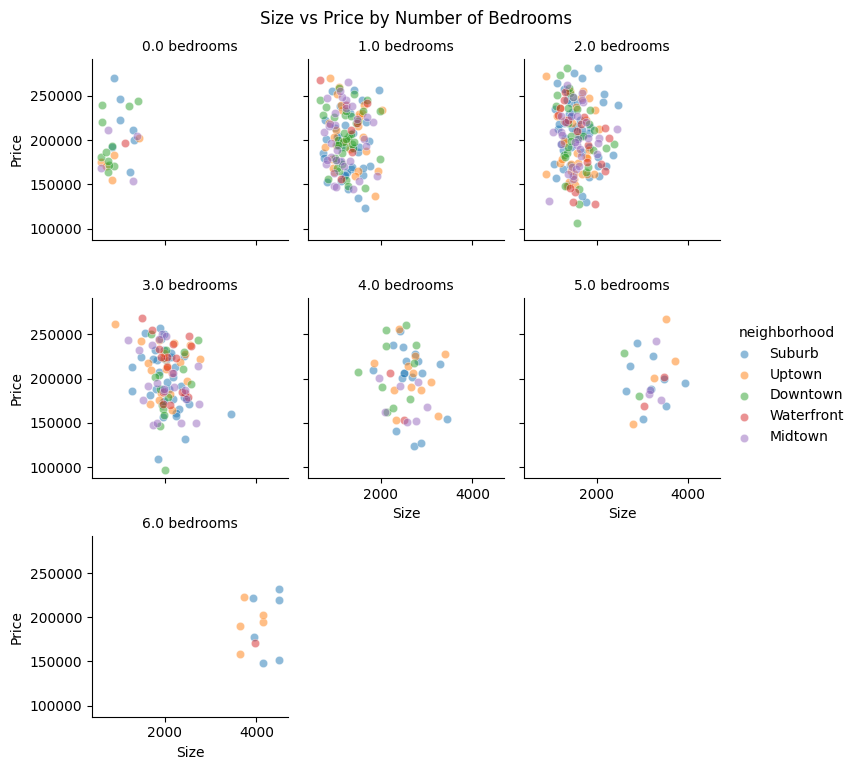

In [21]:
# PART 1 - B. Small Multiples (Faceting)

g = sns.FacetGrid(
    df,
    col="bedrooms",
    hue="neighborhood",
    height=2.5,
    col_wrap=3,
    sharex=True,
    sharey=True
)

g.map_dataframe(sns.scatterplot, x="size", y="price", alpha = .5)

g.add_legend()
g.set_titles(col_template="{col_name} bedrooms")
g.set_axis_labels("Size", "Price")

g.fig.suptitle("Size vs Price by Number of Bedrooms", y=1.02)


------------------------------------------------------------------------

## C. Distribution and Categorical Plots

1.  Create a histogram of `price`.
2.  Create a density plot of `price`.
3.  Create a boxplot of `price` by `neighborhood`.


### Interpretation (short paragraph)

-   Do neighborhoods differ systematically in price?
-   What visual evidence supports your claim?

Response:
- The neighborhoods are remarkably similar. Waterfront is slightly higher and Midtown is slightly lower, but the spread and variability is fairly similar.

<Axes: xlabel='price', ylabel='Count'>

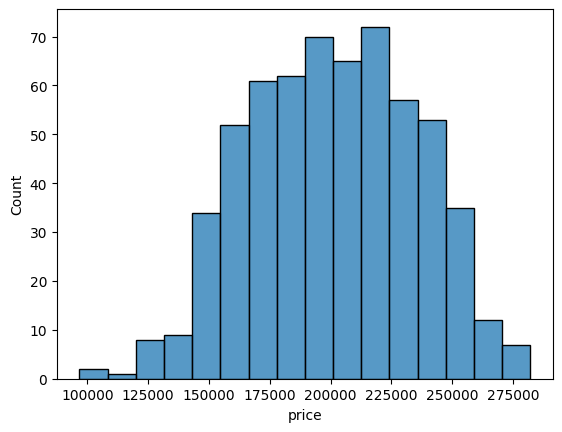

In [22]:
# PART 1 - C. Distribution and Categorical Plots

sns.histplot(data=df, x="price").set_title("Price Distribution")


Text(0.5, 1.0, 'Price Distribution')

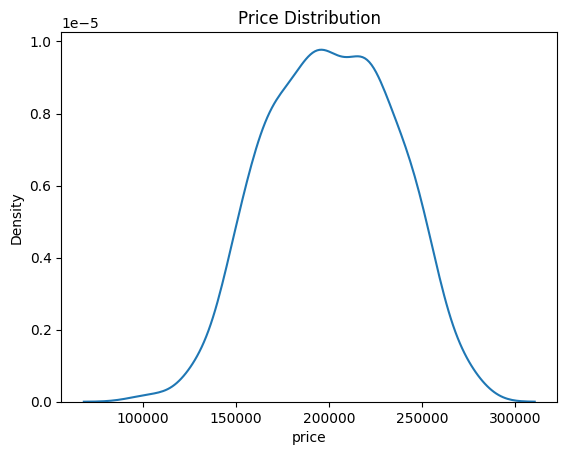

In [24]:
sns.kdeplot(data=df, x="price",).set_title("Price Distribution")

Text(0.5, 1.0, 'Price by Neighborhood')

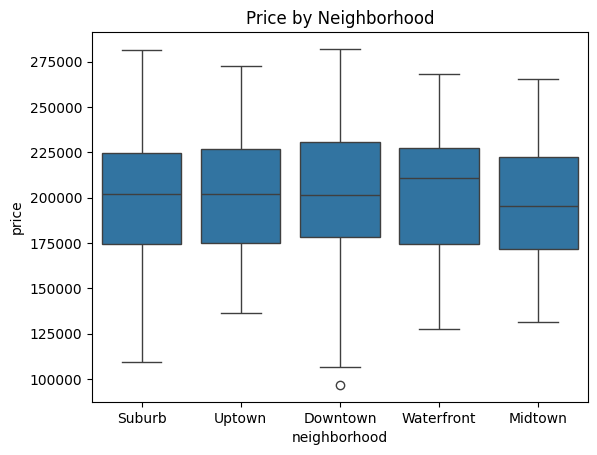

In [25]:
sns.boxplot(data=df, x="neighborhood", y="price").set_title("Price by Neighborhood")

------------------------------------------------------------------------

# Part II -- Linear Regression for Inference (30 pts)

## A. Multiple Regression (R → Python)

In R, the model would be:

 ``` r
lm(price ~ size + bedrooms + neighborhood, data = df)
```

In Python:

1.  Fit the equivalent model using `statsmodels`.
2.  Report:
    -   Coefficient estimates
    -   Standard errors
    -   R²

In [26]:
# Part 2.A - Multiple Regression (R → Python)
import statsmodels.formula.api as smf

model = smf.ols(
    formula="price ~ size + bedrooms + C(neighborhood)",
    data=df
).fit()

# ── 3. Report ────────────────────────────────────────────────────
print(model.summary())          # full table (coef, SE, t, p, CI)
print(model.params)             # coefficient estimates
print(model.bse)                # standard errors
print("R²:", model.rsquared)   # R²
print("Adj R²:", model.rsquared_adj)


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.460
Date:                Thu, 26 Mar 2026   Prob (F-statistic):              0.190
Time:                        23:50:57   Log-Likelihood:                -6212.8
No. Observations:                 524   AIC:                         1.244e+04
Df Residuals:                     517   BIC:                         1.247e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

------------------------------------------------------------------------

## Part 2.B - Interpretation

Answer clearly:

1.  *Interpret the coefficient on **size**, explicitly stating what is being held constant.*
    
    - For every 1 square foot increase in size, the predicted price decreases by about $10.93 — holding bedrooms and neighborhood constant.

    
2.  Is size statistically significant? How do you know?
      - Yes and we know because the p-value is .010 and this is below the standard threshold of 0.05. The |t-statistic| is also above 2 and the 95% confidence interval does not cross 0.


3.  What does R² tell us in this context?
     - R² = 0.017, which means the model explains only about 1.7% of the variation in house prices. Therefore these variables are not helpful in telling us about why the cost could vary.



------------------------------------------------------------------------

# Part III -- Prediction Workflow (20 pts)

Now switch goals: **Prediction instead of explanation**

1.  Split the data into training and test sets.
2.  Fit linear regression using `scikit-learn`.
3.  Compute:
    -   RMSE (on test set)
    -   R² (on test set)
------------------------------------------------------------------------

## Short Answer

-   Why does scikit-learn not report p-values?
    - It is not meant to. p-values are a tool to understand if the relationship is statistically significant or just noise. This is an explaination variable and scikit-learn doesn't care why a variable matters, only whether including it makes predictions better or worse.
-   Which workflow would you use for:
    -   Explanation?
         - I would use `statsmodel`
    -   Prediction?
         - I would use `scikit-learn`
-   Why are these different goals?
    - Explanation asks "what causes what and can we trust that finding?". Prediction asks "given what I know right now, what's my best guess?" A good answer to one question is often a bad answer to the other. That's why they need different tools, different metrics, and different ways of thinking.

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df[["size", "bedrooms", "neighborhood"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Numeric columns: fill missing with the median value
numeric_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median"))
])

# Categorical column: fill missing with the most common value, then encode
categorical_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(drop="first", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipe,      ["size", "bedrooms"]),
    ("cat", categorical_pipe,  ["neighborhood"])
])

model = Pipeline(steps=[
    ("prep", preprocessor),
    ("reg",  LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):,.0f}")
print(f"R²  : {r2_score(y_test, y_pred):.4f}")

RMSE: 34,875
R²  : -0.0472


In [40]:
print(df[["size", "bedrooms", "neighborhood"]].isnull().sum())

size            53
bedrooms        24
neighborhood     0
dtype: int64





------------------------------------------------------------------------

# Part IV -- Integrated Thinking (10 pts)

Create one polished figure that:

-   Shows size vs price
-   Colors by neighborhood
-   Includes a regression line
-   Has professional formatting

Then write 4--5 sentences:

-   Does the regression model match what you visually observed?
-   Did the visualization help you anticipate the model results?

RESPONSE:

Looking at the chart, bigger houses don't actually seem to cost more — if anything, the regression line tilts slightly downward, which is surprising and counterintuitive. The five neighborhoods are completely mixed together across the whole chart, meaning you can't really tell which neighborhood a house is in just by looking at its price. At any given size — say 1,500 square feet — prices range wildly from around $125k all the way up to $275k, which tells you that square footage alone is a pretty poor clue for what a house actually costs. Overall the chart backs up what the model told us: size and neighborhood together just don't explain house prices very well in this dataset, and there must be other factors (like the age or condition of the house) that are doing most of the work.

------------------------------------------------------------------------

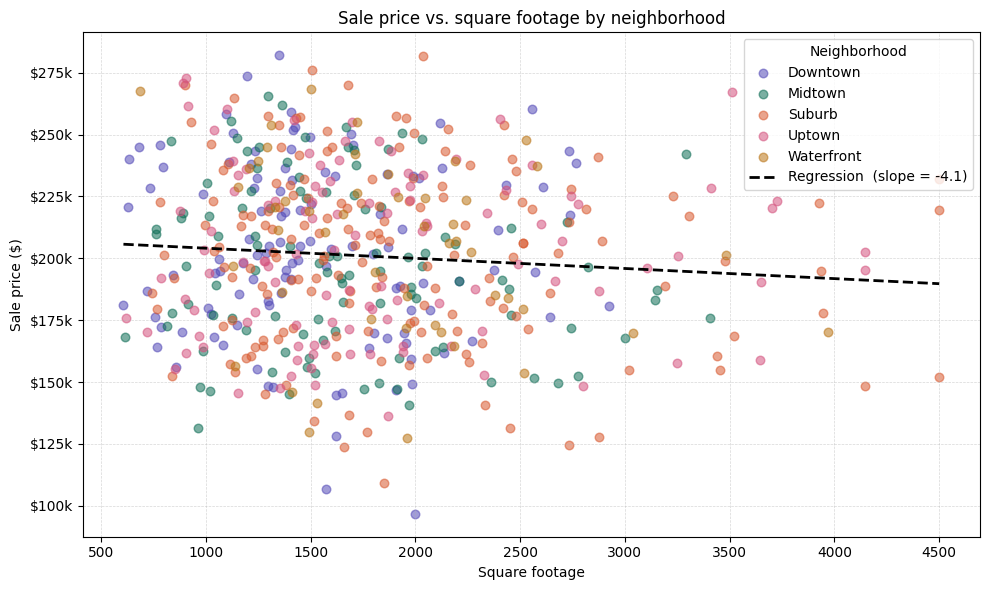

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

COLORS = {
    "Downtown":   "#534AB7",
    "Midtown":    "#0F6E56",
    "Suburb":     "#D85A30",
    "Uptown":     "#D4537E",
    "Waterfront": "#BA7517",
}

# ── Drop missing values first ─────────────────────────────────
df_clean = df[["size", "price", "neighborhood"]].dropna()

fig, ax = plt.subplots(figsize=(10, 6))

# ── Scatter points, one color per neighborhood ────────────────
for hood, group in df_clean.groupby("neighborhood"):
    ax.scatter(
        group["size"], group["price"],
        color=COLORS[hood],
        alpha=0.55, s=38, label=hood
    )

# ── Regression line ───────────────────────────────────────────
m, b = np.polyfit(df_clean["size"], df_clean["price"], deg=1)
x_line = np.linspace(df_clean["size"].min(), df_clean["size"].max(), 300)
ax.plot(x_line, m * x_line + b, color="black", linewidth=2,
        linestyle="--", label=f"Regression  (slope = {m:+.1f})")

# ── Labels ────────────────────────────────────────────────────
ax.set_xlabel("Square footage")
ax.set_ylabel("Sale price ($)")
ax.set_title("Sale price vs. square footage by neighborhood")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
)
ax.legend(title="Neighborhood")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig("size_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()